# Packed bubble plot of antibiotic-resistance genes by ARO parent class


This notebook builds a **packed bubble chart** in which:

- each **bubble is an antibiotic-resistance gene**, and its **area is proportional to
  the number of samples** in which the gene is detected;
- bubbles are **grouped (circle-packed) by their ARO parent class**, each cluster
  drawn in its own colour;
- the parent classes are identified by a **bottom legend** (`n` = number of genes in
  the class), so no floating labels overlap the figure.

Layout uses [`circlify`](https://github.com/elmotec/circlify) (hierarchical circle
packing, the same family of algorithm as D3's `pack`). Gene labels are placed only
when they **measurably fit** inside their own circle, which keeps the figure
collision-free and paper-ready.


In [32]:
import textwrap

import numpy as np
import pandas as pd
import circlify
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from SPARQLWrapper import SPARQLWrapper, JSON

## 1. Query the knowledge graph

Number of samples per resistance gene, together with its ARO class and ARO **parent**
class. Requires the SPARQL endpoint to be reachable.

In [33]:
sparqlQuery = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?gene_name (COUNT(?gene_name) as ?total_nb_occurences) ?aroClass ?aroParentClass ?aroParentClassLabel
FROM <http://www.ontotext.com/explicit>
WHERE {
    ?sample rdf:type sio:001050 .

    ?observableProperty rdf:type sosa:ObservableProperty ;
        rdfs:label 'Resistance gene' .

    ?gene rdf:type ncit:C16612 ;
        rdf:type ?aroClass ;
        rdfs:label ?gene_name .

    ?aroClass rdfs:subClassOf+ aro:3000000 ;
        rdfs:subClassOf ?aroParentClass .

    ?aroParentClass rdfs:subClassOf+ aro:3000000 ;
        rdfs:label ?aroParentClassLabel .

    ?observation sosa:observedProperty ?observableProperty ;
        sio:000332 ?sample ;
        sosa:hasFeatureOfInterest ?gene .

} GROUP BY ?gene_name ?aroClass ?aroParentClass ?aroParentClassLabel
ORDER BY DESC(?total_nb_occurences)
"""

In [34]:
# Requires the SPARQL endpoint to be reachable.
# sparql = SPARQLWrapper("http://localhost:8081/graphdb/repositories/abromics-kg")
sparql = SPARQLWrapper("https://10-54-3-233.gcp.glicid.fr/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery)

data = {"gene": [], "count": [], "aro_class": [],
        "aro_parent_class": [], "aro_parent_class_label": []}
res = sparql.query().convert()
for item in res["results"]["bindings"]:
    data["gene"].append(item["gene_name"]["value"])
    data["count"].append(int(item["total_nb_occurences"]["value"]))
    data["aro_class"].append(item["aroClass"]["value"])
    data["aro_parent_class"].append(item["aroParentClass"]["value"])
    data["aro_parent_class_label"].append(item["aroParentClassLabel"]["value"])

df = pd.DataFrame(data)
print(f"{len(df)} genes, {df['aro_parent_class_label'].nunique()} ARO parent classes")
df.head()

130 genes, 43 ARO parent classes


,gene,count,aro_class,aro_parent_class,aro_parent_class_label
0,ADC-25,83,http://purl.obolibrary.org/obo/ARO_3003868,http://purl.obolibrary.org/obo/ARO_3003846,ADC beta-lactamase without carbapenemase activity
1,sul1,27,http://purl.obolibrary.org/obo/ARO_3000410,http://purl.obolibrary.org/obo/ARO_3004238,sulfonamide resistant sul
2,sul2,26,http://purl.obolibrary.org/obo/ARO_3000412,http://purl.obolibrary.org/obo/ARO_3004238,sulfonamide resistant sul
3,floR,20,http://purl.obolibrary.org/obo/ARO_3002705,http://purl.obolibrary.org/obo/ARO_3003963,flo
4,ant(2'')-Ia,18,http://purl.obolibrary.org/obo/ARO_3000230,http://purl.obolibrary.org/obo/ARO_3007405,ANT(2'')-I


## 2. Filter for readability

Same rule as the original figure: drop genes whose ARO parent class occurs only once
**and** that are seen in fewer than 50 samples. This removes rare, isolated singletons
that would otherwise clutter the plot.

In [35]:
parent_counts = df["aro_parent_class_label"].value_counts()
df_filtered = df[
    ~(
        df["aro_parent_class_label"].map(parent_counts).eq(1)
        & df["count"].lt(50)
    )
].copy()

print(f"{len(df_filtered)} genes kept, "
      f"{df_filtered['aro_parent_class_label'].nunique()} ARO parent classes")

109 genes kept, 22 ARO parent classes


## 2b. Keep only the top-10 most represented ARO parent classes

"Most represented" = **total number of samples** in which the class's genes are
detected (the sum of the bubble sizes for that class). This trims the long tail of
small classes so the figure focuses on the dominant ones.

In [36]:
TOP_N = 10

class_total = (df_filtered.groupby("aro_parent_class_label")["count"]
                          .sum().sort_values(ascending=False))
top_classes = class_total.head(TOP_N).index
df_top10 = df_filtered[df_filtered["aro_parent_class_label"].isin(top_classes)].copy()

print(f"kept top {TOP_N} classes -> {df_top10['gene'].nunique()} genes, "
      f"{df_top10['count'].sum()} total sample detections")
class_total.head(TOP_N)

kept top 10 classes -> 83 genes, 438 total sample detections


aro_parent_class_label
OXA-51-like beta-lactamase                                    83
ADC beta-lactamase without carbapenemase activity             83
sulfonamide resistant sul                                     61
major facilitator superfamily (MFS) antibiotic efflux pump    49
trimethoprim resistant dihydrofolate reductase dfr            48
CTX-M beta-lactamase                                          34
ANT(3'')-Ia                                                   27
chloramphenicol acetyltransferase (CAT)                       23
CMY beta-lactamase                                            16
quinolone resistance protein (qnr)                            14
Name: count, dtype: int64

## 3. Bubble-plot function

`circlify` needs a hierarchical structure: one node per **parent class**, each with a
`datum` (its total sample count) and `children` (its genes, each sized by sample
count). Parent classes are ordered by total count so the largest cluster is packed
centrally.

Readability choices for print:

- **Colour = 22-class qualitative palette** (Trubetskoy); identity is confirmed by the
  legend, so near colours are never the sole cue.
- **Gene labels are measured** with the renderer and drawn only when the text box fits
  inside 92 % of its circle at `>= min_fontsize`; smaller bubbles stay unlabeled
  (their class is still readable from colour + legend). This guarantees no overflow and
  no collisions between neighbouring labels.
- **Label colour adapts to the bubble**: white on dark fills (e.g. navy `OXA-2-like`,
  maroon `AAC(6')-II`), black on light fills, chosen by the WCAG luminance crossover.
- **Legend at the bottom**, multi-column, frameless — collision-free by construction.

In [37]:
# 22 visually distinct colours (Trubetskoy) — one per ARO parent class
PALETTE = [
    "#e6194B", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990", "#dcbeff",
    "#9A6324", "#800000", "#aaffc3", "#808000", "#ffd8b1", "#000075",
    "#a9a9a9", "#e6beff", "#00a3a3", "#c71585",
]


def ideal_text_color(fill, alpha=0.85, bg=(1.0, 1.0, 1.0)):
    """Return 'white' or 'black', whichever is more legible on `fill`.

    The bubble is drawn at `alpha` over a (near-white) background, so we judge
    contrast against the *blended* colour. The threshold is the WCAG luminance at
    which white and black text give equal contrast (L ~= 0.179)."""
    r, g, b = mcolors.to_rgb(fill)
    r = alpha * r + (1 - alpha) * bg[0]
    g = alpha * g + (1 - alpha) * bg[1]
    b = alpha * b + (1 - alpha) * bg[2]
    lin = lambda u: u / 12.92 if u <= 0.03928 else ((u + 0.055) / 1.055) ** 2.4
    L = 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)
    return "white" if L < 0.179 else "black"


def packed_bubble_plot(df, fig_inches=20, min_fontsize=6.5,
                       legend_ncol=3, palette=PALETTE):
    """Packed bubble chart of genes grouped by ARO parent class.

    Bubble area = sample count; cluster = ARO parent class.
    Returns (fig, ax, n_unlabeled).
    """
    # --- hierarchy for circlify (largest cluster first -> central placement) ---
    order = (df.groupby("aro_parent_class_label")["count"].sum()
               .sort_values(ascending=False).index.tolist())
    hierarchy = []
    for cls in order:
        grp = df[df["aro_parent_class_label"] == cls].sort_values("count", ascending=False)
        hierarchy.append({
            "id": cls,
            "datum": int(grp["count"].sum()),
            "children": [{"id": g, "datum": int(n)}
                         for g, n in zip(grp["gene"], grp["count"])],
        })

    circles = circlify.circlify(
        hierarchy, show_enclosure=True,
        target_enclosure=circlify.Circle(x=0, y=0, r=1),
    )
    level1 = [c for c in circles if c.level == 1 and c.ex]  # parent-class enclosures
    level2 = [c for c in circles if c.level == 2 and c.ex]  # gene bubbles

    gene2class = dict(zip(df["gene"], df["aro_parent_class_label"]))
    class_color = {cls: palette[i % len(palette)] for i, cls in enumerate(order)}
    ngenes = df["aro_parent_class_label"].value_counts().to_dict()

    # --- canvas ---
    lim = 1.05
    fig, ax = plt.subplots(figsize=(fig_inches, fig_inches),
                           facecolor="white")
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axis("off")
    ax.set_facecolor("white")

    # cluster backgrounds (light tint + coloured rim)
    for c in level1:
        col = class_color[c.ex["id"]]
        ax.add_patch(plt.Circle((c.x, c.y), c.r, facecolor=col, alpha=0.12,
                                edgecolor=col, linewidth=1.5, zorder=1))
    # gene bubbles
    for c in level2:
        col = class_color[gene2class[c.ex["id"]]]
        ax.add_patch(plt.Circle((c.x, c.y), c.r, facecolor=col, alpha=0.85,
                                edgecolor="white", linewidth=1.2, zorder=2))

    # gene labels — keep only those that measurably fit inside their circle
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    n_unlabeled = 0
    for c in level2:
        gene = c.ex["id"]
        col = class_color[gene2class[gene]]
        x0, y0 = ax.transData.transform((c.x, c.y))
        x1, _ = ax.transData.transform((c.x + c.r, c.y))
        r_px = abs(x1 - x0)
        t = ax.text(c.x, c.y, gene, ha="center", va="center",
                    fontsize=15, zorder=3, color=ideal_text_color(col))
        bb = t.get_window_extent(renderer)
        fs = 15 * (0.92 * r_px / (0.5 * np.hypot(bb.width, bb.height)))
        if fs >= min_fontsize:
            t.set_fontsize(min(fs, 30))
        else:
            t.remove()
            n_unlabeled += 1

    # legend — one entry per parent class, collision-free at the bottom
    handles = [Patch(facecolor=class_color[cls], edgecolor="white",
                     label=f"{cls}  (n={ngenes[cls]})") for cls in order]
    leg = ax.legend(handles=handles, title="Top-10 ARO parent classes (n = antibiotic resistance genes)",
                    loc="upper center", bbox_to_anchor=(0.5, -0.02),
                    ncol=legend_ncol, frameon=False, fontsize=30, title_fontsize=40,
                    handlelength=1.4, handleheight=1.4, columnspacing=1.8,
                    labelspacing=0.7, borderaxespad=0)
    leg.get_title().set_fontweight("bold")
    # keep legend text readable regardless of any dark style active in the kernel
    leg.get_title().set_color("black")
    for txt in leg.get_texts():
        txt.set_color("black")
    return fig, ax, n_unlabeled

## 4. Render and export

18 bubbles left unlabeled (too small to fit a legible name; their class is still shown by colour + legend)


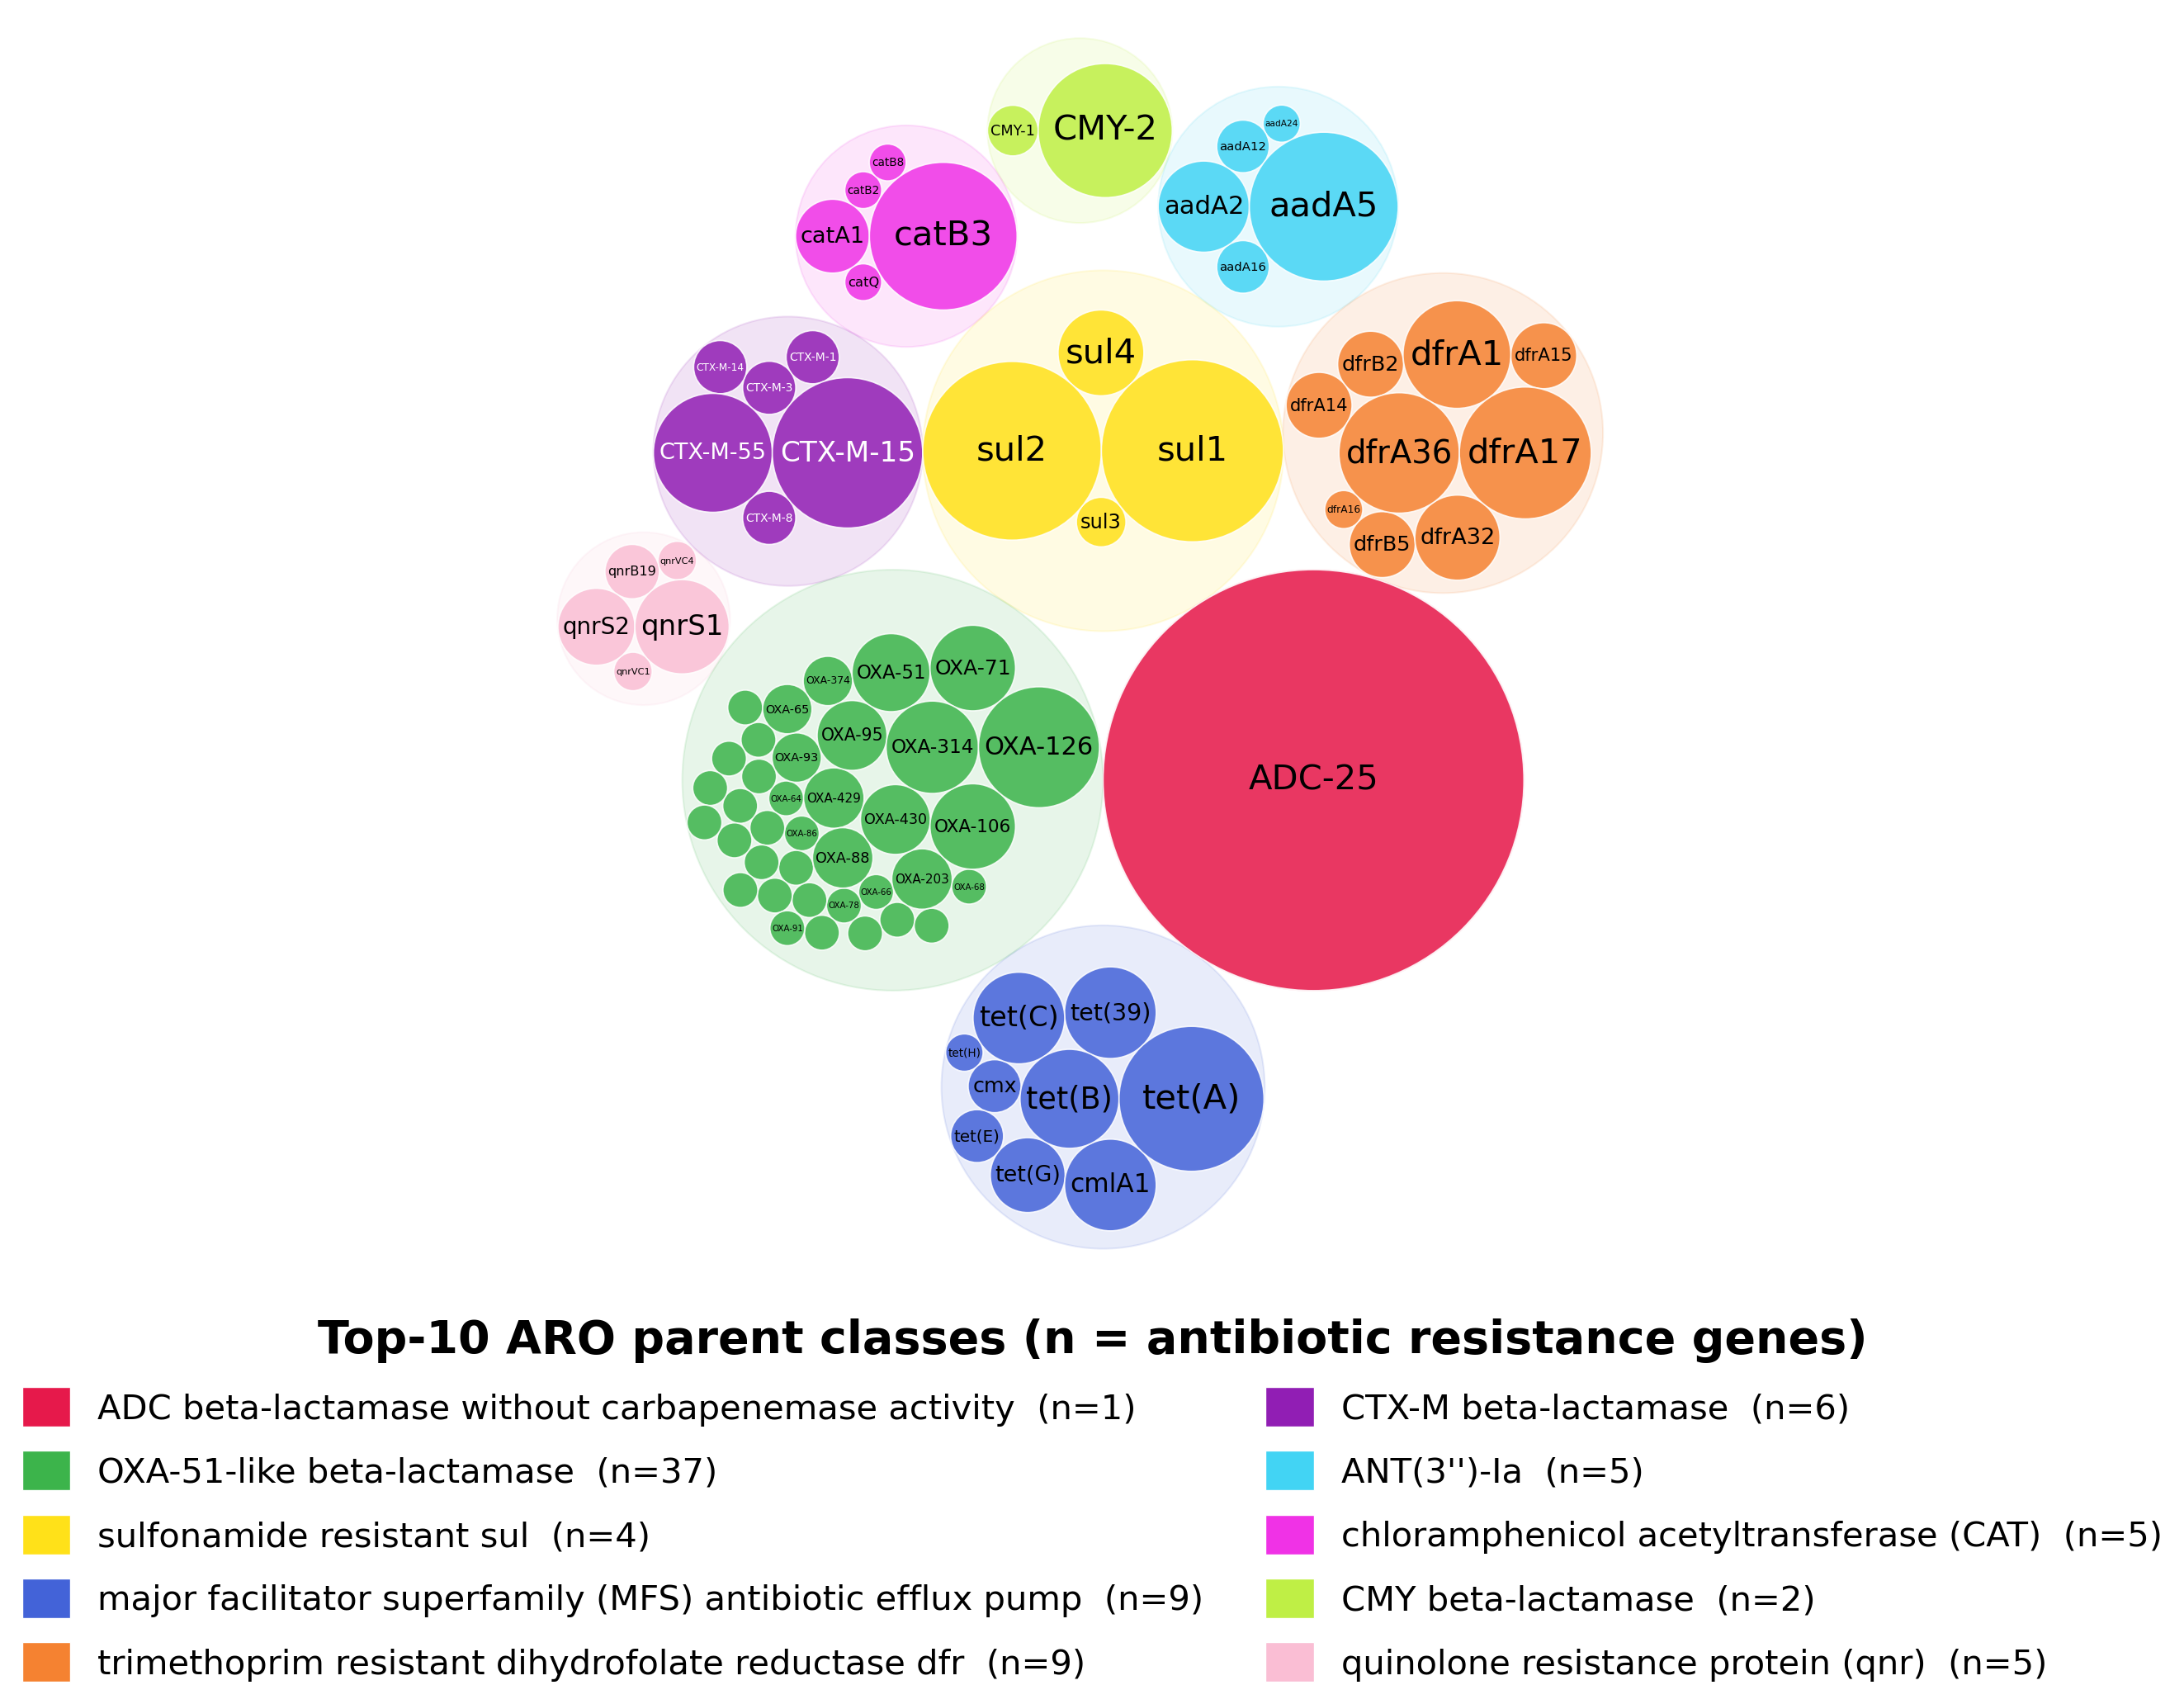

In [38]:
fig, ax, n_unlabeled = packed_bubble_plot(df_top10, fig_inches=20, min_fontsize=6.5, legend_ncol=2)
print(f"{n_unlabeled} bubbles left unlabeled (too small to fit a legible name; "
      f"their class is still shown by colour + legend)")

# vector PDF for the paper (crisp at any zoom) + high-DPI PNG for previews
fig.savefig("figure-2-circlify.pdf", bbox_inches="tight", facecolor="white")
fig.savefig("figure-2-circlify.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()